In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [17]:
df = pd.read_csv('data/AB_US_2023.csv')

df.head()

C:\Users\gjper\AppData\Local\Temp\ipykernel_2892\2660343638.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/AB_US_2023.csv')


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,NaN,Western Addition,37.77028,-122.43317,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco
1,5858,Creative Sanctuary,8904,Philip And Tania,NaN,Bernal Heights,37.74474,-122.42089,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,NaN,Haight Ashbury,37.76555,-122.45213,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco
3,8339,Historic Alamo Square Victorian,24215,Rosy,NaN,Western Addition,37.77564,-122.43642,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,NaN,Mission,37.76030,-122.42197,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232147 entries, 0 to 232146
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              232147 non-null  int64  
 1   name                            232131 non-null  object 
 2   host_id                         232147 non-null  int64  
 3   host_name                       232134 non-null  object 
 4   neighbourhood_group             96500 non-null   object 
 5   neighbourhood                   232147 non-null  object 
 6   latitude                        232147 non-null  float64
 7   longitude                       232147 non-null  float64
 8   room_type                       232147 non-null  object 
 9   price                           232147 non-null  int64  
 10  minimum_nights                  232147 non-null  int64  
 11  number_of_reviews               232147 non-null  int64  
 12  last_review     

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.321470e+05,2.321470e+05,232147.000000,232147.000000,232147.000000,232147.000000,232147.000000,183062.000000,232147.000000,232147.000000,232147.000000
mean,2.584580e+17,1.582248e+08,36.610585,-98.301436,259.468001,13.495867,40.915230,1.638348,29.879055,180.985686,11.689701
std,3.465985e+17,1.587164e+08,5.126523,19.706929,1024.645918,27.920631,80.649152,1.910812,106.013665,134.715299,20.599954
min,6.000000e+00,2.300000e+01,25.957323,-123.089130,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.638896e+07,2.299242e+07,33.976225,-118.315111,91.000000,2.000000,1.000000,0.310000,1.000000,52.000000,0.000000
50%,4.896307e+07,1.005783e+08,36.190556,-97.727670,149.000000,3.000000,9.000000,1.000000,2.000000,175.000000,3.000000
75%,6.633014e+17,2.686930e+08,40.717440,-77.026222,250.000000,30.000000,43.000000,2.420000,10.000000,321.000000,16.000000
max,8.581014e+17,5.069384e+08,47.734010,-70.996000,100000.000000,1250.000000,3091.000000,101.420000,1003.000000,365.000000,1314.000000


In [8]:
df.isnull().sum()

id                                     0
name                                  16
host_id                                0
host_name                             13
neighbourhood_group               135647
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                                  0
minimum_nights                         0
number_of_reviews                      0
last_review                        49085
reviews_per_month                  49085
calculated_host_listings_count         0
availability_365                       0
number_of_reviews_ltm                  0
city                                   0
dtype: int64

In [9]:
df['price'].mean()

np.float64(259.46800087875357)

In [30]:
media_preco = df['price'].mean()

print(f"${media_preco:.2f}")

$259.47


In [31]:
df['room_type'].value_counts()

room_type
Entire home/apt    169142
Private room        59759
Shared room          2276
Hotel room            970
Name: count, dtype: int64

In [32]:
# Visualizações

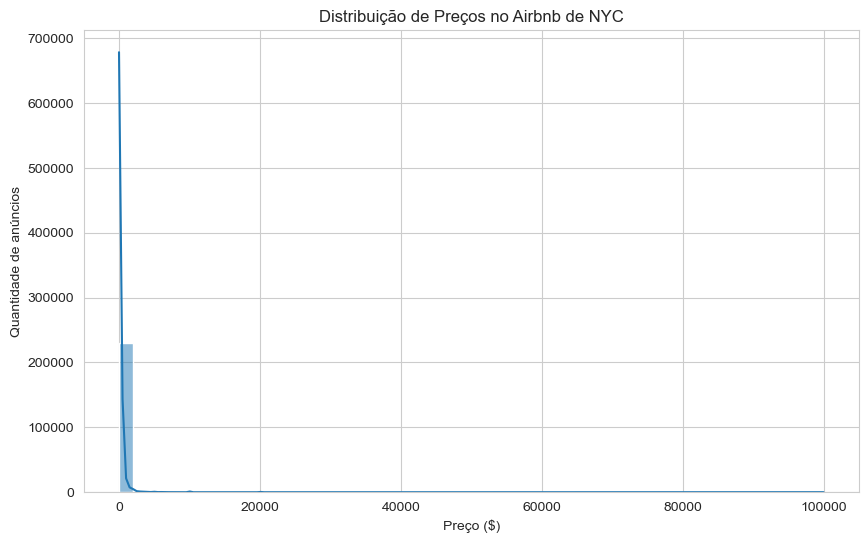

In [48]:
sns.histplot(df['price'], bins=50, kde=True)

plt.title("Distribuição de Preços no Airbnb de NYC")
plt.xlabel("Preço ($)")
plt.ylabel("Quantidade de anúncios")
import matplotlib.ticker as ticker

plt.savefig("images/distribuicao_precos.png")

plt.show()

In [45]:
df_filtrado = df[df['price'] < 1500]

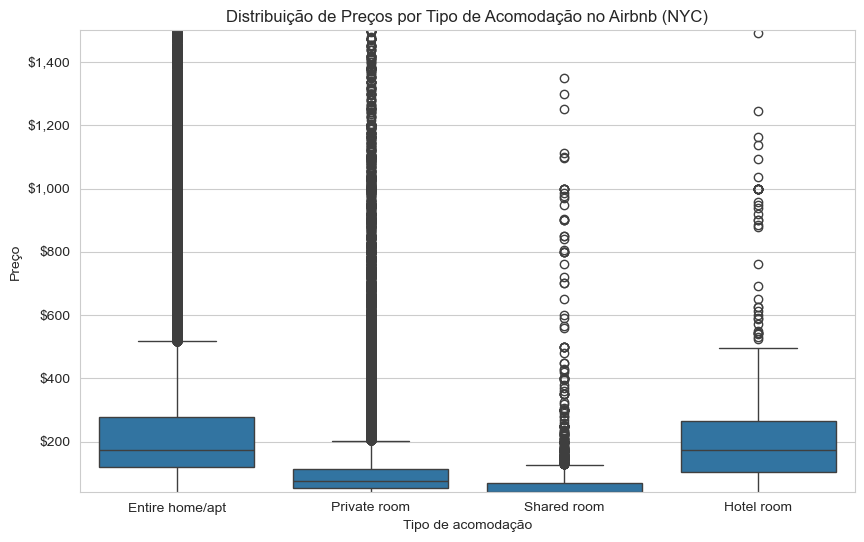

In [49]:
ax = sns.boxplot(x='room_type', y='price', data=df_filtrado)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.title("Distribuição de Preços por Tipo de Acomodação no Airbnb (NYC)")
plt.xlabel("Tipo de acomodação")
plt.ylabel("Preço")

plt.ylim(40,1500)

plt.savefig("images/preco_por_tipo.png")

plt.show()

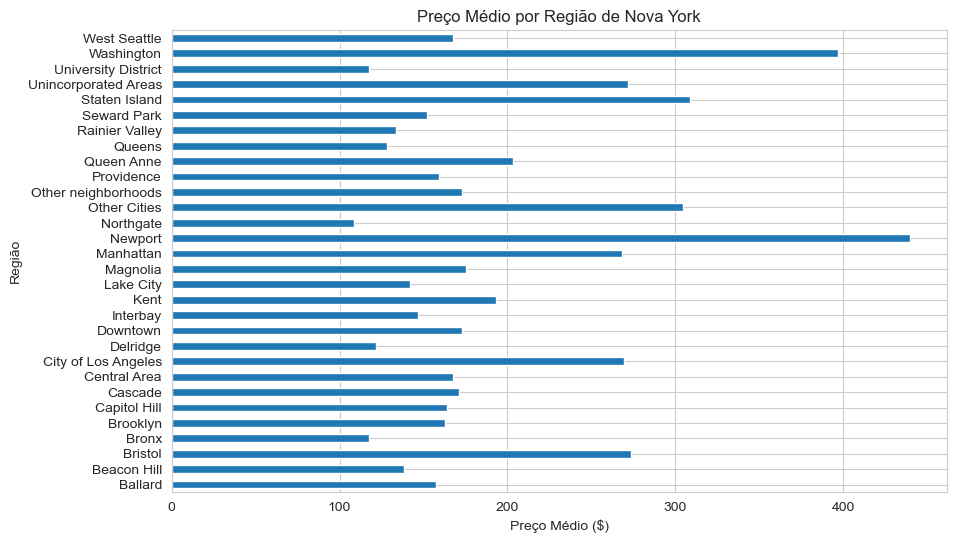

In [50]:
media_preco = df.groupby('neighbourhood_group')['price'].mean().round(2)

media_preco.plot(kind='barh')

plt.title("Preço Médio por Região de Nova York")
plt.xlabel("Preço Médio ($)")
plt.ylabel("Região")

plt.savefig("images/preco_por_regiao.png")

plt.show()

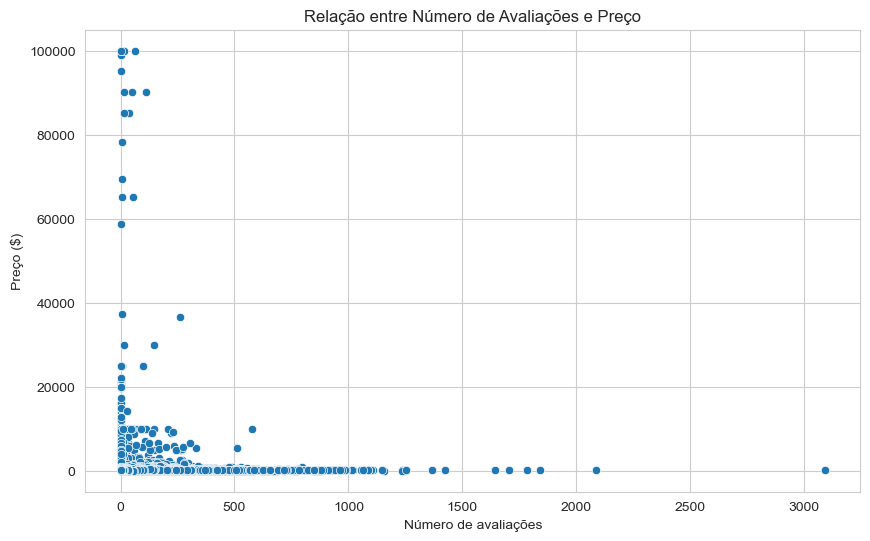

In [51]:
sns.scatterplot(x='number_of_reviews', y='price', data=df)

plt.title("Relação entre Número de Avaliações e Preço")
plt.xlabel("Número de avaliações")
plt.ylabel("Preço ($)")

plt.savefig("images/reviews_vs_preco.png")

plt.show()

In [37]:
# Conclusão da análise

# Manhattan apresenta os maiores preços médios.
# A maioria das hospedagens custa menos de $200.
# Entire home/apartment possui maior variação de preço.
# O número de reviews não parece influenciar diretamente o preço.